In [10]:
import os
import pickle
import numpy as np
import pandas as pd
import neurokit2 as nk
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.signal import butter, filtfilt, find_peaks

from sklearn.model_selection import LeaveOneGroupOut
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.neighbors import KNeighborsClassifier

from xgboost import XGBClassifier
import scipy.signal as scisig
from scipy.signal import resample

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn.functional as F
import onnx

from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix,
    matthews_corrcoef, roc_auc_score
)

import warnings
warnings.filterwarnings(
    "ignore",
    module="neurokit2"
)

In [ ]:
DATA_PATH = "../data/WESAD"
LABEL_WINDOW = 2
INPUT_WINDOW = 60
SAMPLE_FS = {'ACC': 32, 'BVP': 64, 'TEMP': 4, 'LABEL': 700}
USE_FREQ_HRV = False

SUBJECT_IDS = (
    [f"S{i}" for i in range(2, 12)] +
    [f"S{i}" for i in range(13, 18)]
)

def load_subject(path):
    with open(path, "rb") as f:
        return pickle.load(f, encoding="latin1")

def downsample_label(x, fs_high, fs_low):
    x = np.asarray(x[max(0, (INPUT_WINDOW-LABEL_WINDOW) * fs_high):])
    T = len(x) / fs_high
    n_out = int(round(T * fs_low))

    # time stamps for input samples
    t = np.arange(len(x)) / fs_high

    # bin edges for output samples (uniform in time)
    edges = np.linspace(0, T, n_out + 1)

    y = np.empty(n_out, dtype=int)
    for i in range(n_out):
        mask = (t >= edges[i]) & (t < edges[i+1])

        if mask.any():
            l = np.bincount(x[mask], minlength=8)[1:5].argmax()
            y[i] = l if l != 3 else 0
        else:
            # rare edge case if rounding creates an empty bin
            y[i] = y[i-1] if i > 0 else x[0]
    return y

def upsample(low_signal, high_signal, fs_high, fs_low):
    upsample_factor = fs_high / fs_low

    # Compute target length
    target_len = len(high_signal)

    # Repeat each low-frequency sample
    indices = np.floor(np.arange(target_len) / upsample_factor).astype(int)
    indices = np.clip(indices, 0, len(low_signal) - 1)

    return low_signal[indices]

def filterSignalFIR(data, cutoff=0.4, numtaps=64):
    f = cutoff / (32 / 2.0)
    FIR_coeff = scisig.firwin(numtaps, f)
    return scisig.lfilter(FIR_coeff, 1, data)

def dom_nonzero_freq(signal, fs_hz):
    """
    Returns most dominant non-zero frequency via fft
    """
    T, K, C = signal.shape
    y = np.fft.rfft(signal, axis = 0)
    yf = np.fft.rfftfreq(T, 1/fs_hz)
    mag = np.abs(y)
    mag[0, :, :] = 0
    idx = np.argmax(mag, axis = 0)
    return yf[idx]


In [ ]:
# =========================== Data processing: Time Series data with HRV ===================================================
x = []
y = []

for sid in SUBJECT_IDS:
    print(sid)
    subject = load_subject(f"{DATA_PATH}/{sid}/{sid}.pkl")

    labels = np.array(subject['label'])
    labels = downsample_label(labels, 700, 1.0/LABEL_WINDOW)

    temp = np.array(subject['signal']['wrist']['TEMP'])

    bvp = np.array(subject['signal']['wrist']['BVP'])
    bvp_clean = nk.ppg_clean(bvp, sampling_rate=64)
    peaks, hrv_info = nk.ppg_peaks(bvp_clean, sampling_rate=64)

    acc = np.array(subject['signal']['wrist']['ACC'])
    

    for start in range(0, len(labels)):
        temp_s = temp[start * LABEL_WINDOW * 4: start * LABEL_WINDOW * 4 + INPUT_WINDOW * 4]
        bvp_s = bvp[start * LABEL_WINDOW * 64: start * LABEL_WINDOW * 64 + INPUT_WINDOW * 64]
        acc_s = acc[start * LABEL_WINDOW * 32: start * LABEL_WINDOW * 32 + INPUT_WINDOW * 32]
        label_s = labels[start]

        if np.count_nonzero(peaks[start * LABEL_WINDOW * 64: start * LABEL_WINDOW * 64 + INPUT_WINDOW * 64]) <= 5 or len(bvp_s) != INPUT_WINDOW * 64:
            continue

        hrv = []
        if USE_FREQ_HRV:
            hrv = nk.hrv(peaks[start * LABEL_WINDOW * 64: start * LABEL_WINDOW * 64 + INPUT_WINDOW * 64], sampling_rate=64, show=False)
        else:
            hrv = nk.hrv_time(peaks[start * LABEL_WINDOW * 64: start * LABEL_WINDOW * 64 + INPUT_WINDOW * 64], sampling_rate=64, show=False)
        

        data = [temp_s[:,0], bvp_s[:,0], acc_s[:,0], acc_s[:,1], acc_s[:,2], np.array(hrv["HRV_RMSSD"]), np.array(hrv["HRV_SDNN"]), np.array(hrv["HRV_pNN50"])]
        if USE_FREQ_HRV:
            data.append(np.array(hrv["HRV_LF"]))
            data.append(np.array(hrv["HRV_HF"]))
            data.append(np.array(hrv["HRV_LFHF"]))
        x_s = np.concatenate(data)

        shape_size = INPUT_WINDOW * 164 + 6 if USE_FREQ_HRV else INPUT_WINDOW * 164 + 3
        if x_s.shape[0] != shape_size:
            continue
        x.append(x_s)
        y.append(label_s)


x = np.array(x)
y = np.array(y)
print(x.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2, shuffle = True, stratify=y)
    

S2


/tmp/ipykernel_1252795/372622226.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


3840
PPG_Peaks    63
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    63
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    63
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    61
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    63
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    73
dtype: int64
3840
PPG_Peaks    73
dtype: int64
3840
PPG_Peaks    73
dtype: int64
3840
PPG_Peaks    73
dtype: int64
3840
PPG_Peaks    74
dtype: int64
3840
PPG_Peaks    74
dtype: int64
3840
PPG_Peaks    74
dtype: int64
3840
PPG_Peaks    74
dtype: int64
3840
PPG_Peaks    73
dtype: int64
3840
PPG_Peaks

/tmp/ipykernel_1252795/372622226.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


3840
PPG_Peaks    74
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    72
dtype: int64
3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks

...

3840
PPG_Peaks    41
dtype: int64
3840
PPG_Peaks    41
dtype: int64
3840
PPG_Peaks    43
dtype: int64
3840
PPG_Peaks    43
dtype: int64
3840
PPG_Peaks    45
dtype: int64
3840
PPG_Peaks    46
dtype: int64
3840
PPG_Peaks    47
dtype: int64
3840
PPG_Peaks    47
dtype: int64
3840
PPG_Peaks    50
dtype: int64
3840
PPG_Peaks    50
dtype: int64
3840
PPG_Peaks    52
dtype: int64
3840
PPG_Peaks    55
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    58
dtype: int64
3840
PPG_Peaks    58
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    57
dtype: int64
3840
PPG_Peaks    57
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    56
dtype: int64
3840
PPG_Peaks    58
dtype: int64
3840
PPG_Peaks    59
dtype: int64
3840
PPG_Peaks    62
dtype: int64
3840
PPG_Peaks    63
dtype: int64
3840
PPG_Peaks    64
dtype: int64
3840
PPG_Peaks    64
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks

/tmp/ipykernel_1252795/372622226.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    71
dtype: int64
3840
PPG_Peaks    70
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    69
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    64
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    65
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    66
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    67
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks    68
dtype: int64
3840
PPG_Peaks

/tmp/ipykernel_1252795/372622226.py:13: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  return pickle.load(f, encoding="latin1")


3840
PPG_Peaks    86
dtype: int64
3840
PPG_Peaks    87
dtype: int64
3840
PPG_Peaks    87
dtype: int64
3840
PPG_Peaks    87
dtype: int64
3840
PPG_Peaks    86
dtype: int64
3840
PPG_Peaks    87
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    83
dtype: int64
3840
PPG_Peaks    85
dtype: int64
3840
PPG_Peaks    85
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    85
dtype: int64
3840
PPG_Peaks    85
dtype: int64
3840
PPG_Peaks    85
dtype: int64
3840
PPG_Peaks    86
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    84
dtype: int64
3840
PPG_Peaks    83
dtype: int64
3840
PPG_Peaks    83
dtype: int64
3840
PPG_Peaks    82
dtype: int64
3840
PPG_Peaks    82
dtype: int64
3840
PPG_Peaks    81
dtype: int64
3840
PPG_Peaks    81
dtype: int64
3840
PPG_Peaks    80
dtype: int64
3840
PPG_Peaks    80
dtype: int64
3840
PPG_Peaks    79
dtype: int64
3840
PPG_Peaks

In [ ]:
# =========================== Data processing: WESAD Table ===================================================
x = []
y = []

for sid in SUBJECT_IDS:
    print(sid)
    subject = load_subject(f"{DATA_PATH}/{sid}/{sid}.pkl")

    labels = np.array(subject['label'])
    labels = downsample_label(labels, SAMPLE_FS['LABEL'], 1.0/LABEL_WINDOW)

    temp = np.array(subject['signal']['wrist']['TEMP'])

    bvp = np.array(subject['signal']['wrist']['BVP'])
    bvp_signals, bvp_info = nk.ppg_process(bvp, sampling_rate=64)

    acc = np.array(subject['signal']['wrist']['ACC'])
    #acc = filterSignalFIR(acc)
    

    for start in range(0, len(labels)):
        temp_s = temp[start * LABEL_WINDOW * SAMPLE_FS['TEMP']: start * LABEL_WINDOW * SAMPLE_FS['TEMP'] + INPUT_WINDOW * SAMPLE_FS['TEMP']]
        bvp_s = bvp[start * LABEL_WINDOW * SAMPLE_FS['BVP']: start * LABEL_WINDOW * SAMPLE_FS['BVP'] + INPUT_WINDOW * SAMPLE_FS['BVP']]
        peaks_s = np.array(bvp_signals['PPG_Peaks'][start * LABEL_WINDOW * SAMPLE_FS['BVP']: start * LABEL_WINDOW * SAMPLE_FS['BVP'] + INPUT_WINDOW * SAMPLE_FS['BVP']])
        if np.count_nonzero(peaks_s) <= 3 or len(bvp_s) != INPUT_WINDOW * SAMPLE_FS['BVP']:
            continue
        acc_s = acc[start * LABEL_WINDOW * SAMPLE_FS['ACC']: start * LABEL_WINDOW * SAMPLE_FS['ACC'] + INPUT_WINDOW * SAMPLE_FS['ACC']]
        acc_s = acc_s.reshape(160, 12, 3)
        label_s = labels[start]

        acc_mean = np.mean(acc_s, axis = 0)
        acc_std = np.std(acc_s, axis = 0)
        acc_sum = np.trapezoid(np.abs(acc_s), axis = 0)
        acc_peak_freq = dom_nonzero_freq(acc_s, SAMPLE_FS['ACC'])
        acc_data = np.concatenate([acc_mean.flatten(), acc_std.flatten(), acc_sum.flatten(), acc_peak_freq.flatten()])

        temp_mean = np.mean(temp_s)
        temp_std = np.std(temp_s)
        temp_min = np.min(temp_s)
        temp_max = np.max(temp_s)
        temp_range = temp_max - temp_min
        temp_slope = np.polyfit(np.arange(len(temp_s)), temp_s, 1)[0][0]
        temp_data = [temp_mean, temp_std, temp_min, temp_max, temp_range, temp_slope]
        
        hrv = nk.hrv_time(peaks_s, sampling_rate=SAMPLE_FS['BVP'], show=False) if not USE_FREQ_HRV else nk.hrv(peaks_s, sampling_rate=SAMPLE_FS['BVP'], show=False)
        hr_mean = hrv['HRV_MeanNN']
        hr_std = hrv['HRV_SDNN']
        hrv_rmssd = hrv['HRV_RMSSD']
        hrv_pNN50 = hrv['HRV_pNN50']
        hrv_tinn = hrv['HRV_TINN']
        hrv_data = [hr_mean, hr_std, hrv_rmssd, hrv_pNN50, hrv_tinn]

        if USE_FREQ_HRV:
            hrv_data.append(hrv['HRV_ULF'])
            hrv_data.append(hrv['HRV_LF'])
            hrv_data.append(hrv['HRV_HF'])
            hrv_data.append(hrv['HRV_VHF'])
            hrv_data.append(hrv['HRV_LFHF'])
            hrv_data.append(hrv['HRV_LFn'])
            hrv_data.append(hrv['HRV_HFn'])

        x_s = np.array(np.concatenate([acc_data, temp_data, np.array(hrv_data).squeeze(1)]))

        x.append(x_s)
        y.append(label_s)


x = np.array(x)
y = np.array(y)
print(x.shape)
print(y.shape)

X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2, shuffle = True, stratify=y)
    


S2
[0.01666667 0.01666667 0.06666667]
[0.01666667 0.01666667 0.06666667]
[0.01666667 0.01666667 0.06666667]
[0.01666667 0.01666667 0.05      ]
[0.01666667 0.01666667 0.05      ]
[0.01666667 0.01666667 0.05      ]
[0.01666667 0.01666667 0.05      ]
[0.01666667 0.01666667 0.05      ]
[0.01666667 0.01666667 0.05      ]
[0.01666667 0.01666667 0.03333333]
[0.01666667 0.01666667 0.03333333]
[0.01666667 0.01666667 0.03333333]
[0.01666667 0.01666667 0.03333333]
[0.01666667 0.01666667 0.03333333]
[0.01666667 0.01666667 0.03333333]
[0.01666667 0.01666667 0.03333333]
[0.01666667 0.01666667 0.03333333]
[0.01666667 0.01666667 0.03333333]
[0.06666667 0.01666667 0.01666667]
[0.06666667 0.01666667 0.01666667]
[0.06666667 0.01666667 0.01666667]
[0.06666667 0.01666667 0.01666667]
[0.06666667 0.01666667 0.01666667]
[0.05       0.01666667 0.01666667]
[0.05       0.01666667 0.01666667]
[0.05       0.01666667 0.01666667]
[0.06666667 0.01666667 0.01666667]
[0.06666667 0.01666667 0.01666667]
[0.06666667 0.016

KeyboardInterrupt: 

In [66]:
np.save("x_extracted_no_freq_5sACC.npy", x)
np.save("y_extracted_no_freq_5sACC.npy", y)

In [36]:
# ================ Load preprocessed data ==========================================
x = np.load("../data/Processed/x_extracted_no_freq.npy")
y = np.load("../data/Processed/y_extracted_no_freq.npy")
print(x.shape)
print(y.shape)
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=2, shuffle = True, stratify=y)
# X_train = x[:34233]
# y_train = y[:34233]
# X_test = x[34233:]
# y_test = y[34233:]


(42792, 23)
(42792,)


/venv/main/lib/python3.12/site-packages/xgboost/training.py:199: UserWarning: [18:10:00] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "scale_pos_weight" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[0]	validation_0-mlogloss:0.78517	validation_0-merror:0.17899
[1]	validation_0-mlogloss:0.76685	validation_0-merror:0.17899
[2]	validation_0-mlogloss:0.75049	validation_0-merror:0.17899
[3]	validation_0-mlogloss:0.73620	validation_0-merror:0.17899
[4]	validation_0-mlogloss:0.72356	validation_0-merror:0.17899
[5]	validation_0-mlogloss:0.71229	validation_0-merror:0.17899
[6]	validation_0-mlogloss:0.70137	validation_0-merror:0.17899
[7]	validation_0-mlogloss:0.69179	validation_0-merror:0.17899
[8]	validation_0-mlogloss:0.68076	validation_0-merror:0.17899
[9]	validation_0-mlogloss:0.67100	validation_0-merror:0.17899
[10]	validation_0-mlogloss:0.66292	validation_0-merror:0.17899
[11]	validation_0-mlogloss:0.65365	validation_0-merror:0.17899
[12]	validation_0-mlogloss:0.64461	validation_0-merror:0.17946
[13]	validation_0-mlogloss:0.63680	validation_0-merror:0.17946
[14]	validation_0-mlogloss:0.63101	validation_0-merror:0.18086
[15]	validation_0-mlogloss:0.62723	validation_0-merror:0.18086
[1

<Axes: >

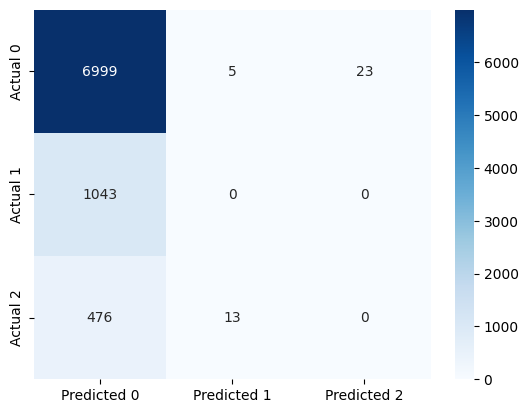

In [27]:
# ===================TEST XGB ======================================
xgb = XGBClassifier(
    n_estimators=30,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
    tree_method = 'hist',
    eval_metric=["mlogloss", "merror"])

xgb.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
)

unique, counts = np.unique(y.copy(), return_counts=True)
pred = xgb.predict(X_test)
cm = confusion_matrix(y_test, pred)
f1 = f1_score(np.array(y_test), np.array(pred), average='micro', labels=unique)
print(f1)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Predicted {i}" for i in range(len(unique))],
    yticklabels=[f"Actual {i}" for i in range(len(unique))]
)

In [37]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(x.shape[1], 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, 16), 
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(16, 3),
        )

    def forward(self, x):
        return self.net(x)

class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(in_channels=1, out_channels=8, kernel_size=3, stride=1, padding=1)
        self.pool = nn.MaxPool1d(kernel_size=2, stride=2, padding=0)
        self.conv2 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=3, stride=1, padding=1)
        self.relu = nn.ReLU()

        self.classifier = nn.Sequential(
            nn.Flatten(),                  
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(),
            nn.Linear(128, 3)
        )


    def forward(self, x):
        x = self.relu(self.conv1(x.unsqueeze(dim=1)))
        print(x.shape)
        x = self.pool(x)
        print(x.shape)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        print(x.shape)

        return self.classifier(x)

tensor([0.4068, 2.8545, 5.2230], device='cuda:0', dtype=torch.float64)
Epoch [1/2000] - Loss: 1.0943 - Val_Acc: 0.1309732445379133 - Val_Loss: 0.2708927279529037
Epoch [2/2000] - Loss: 1.0587 - Val_Acc: 0.4425750671807454 - Val_Loss: 0.2590440269583222
Epoch [3/2000] - Loss: 1.0082 - Val_Acc: 0.6214511041009464 - Val_Loss: 0.2454133730333935
Epoch [4/2000] - Loss: 0.9503 - Val_Acc: 0.6345367449468395 - Val_Loss: 0.24116556587139248
Epoch [5/2000] - Loss: 0.8988 - Val_Acc: 0.6167776609416988 - Val_Loss: 0.221295489760855
Epoch [6/2000] - Loss: 0.8667 - Val_Acc: 0.5880359855123262 - Val_Loss: 0.2147625900253637
Epoch [7/2000] - Loss: 0.8340 - Val_Acc: 0.5846477392218717 - Val_Loss: 0.20568482339654054
Epoch [8/2000] - Loss: 0.8086 - Val_Acc: 0.5723799509288469 - Val_Loss: 0.20209946537119694
Epoch [9/2000] - Loss: 0.7920 - Val_Acc: 0.5833625423530786 - Val_Loss: 0.2182085069473904
Epoch [10/2000] - Loss: 0.7691 - Val_Acc: 0.575534525061339 - Val_Loss: 0.18756289306495122
Epoch [11/2000] 

<Axes: >

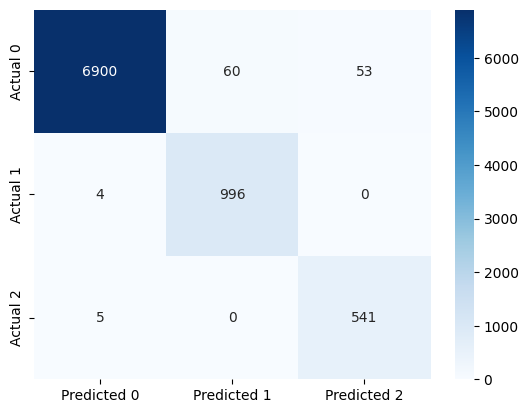

In [39]:
# ========================= TEST NN ==============================
device = "cuda:0"
model = 0
model = MLP().to(torch.float64).to(device)

unique, counts = np.unique(y.copy(), return_counts=True)
class_weight = torch.tensor([len(y) / (len(unique) * counts[i]) for i in range(len(unique))]).to(torch.float64).to(device)
print(class_weight)
criterion = nn.CrossEntropyLoss(weight=class_weight)
optimizer = optim.AdamW(model.parameters(), lr=1e-4)


scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
train_dataset = TensorDataset(torch.tensor(X_train_scaled), torch.tensor(y_train))
test_dataset = TensorDataset(torch.tensor(X_test_scaled), torch.tensor(y_test))

dataloader_tr = DataLoader(train_dataset, batch_size=256, shuffle=True)
dataloader_te = DataLoader(test_dataset, batch_size=256)


num_epochs = 2000

for epoch in range(num_epochs):
    model.train()
    total_loss = 0.0

    for batch_x, batch_y in dataloader_tr:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device)

        # Forward pass
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        if torch.isnan(batch_x).any() or torch.isinf(batch_x).any():
            print('invalid input detected')

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    model.eval()
    correct = 0
    total = 0
    val_loss_total = 0.0

    with torch.no_grad():
        for tx, ty in dataloader_te:
            tx, ty = tx.to(device), ty.to(device)

            logits = model(tx)
            preds = logits.argmax(dim=1)
            val_loss = criterion(logits, ty)
            val_loss_total += loss.item()

            correct += (preds == ty).sum().item()
            total += ty.size(0)

    val_accuracy = correct / total
    avg_loss = total_loss / len(dataloader_tr)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.4f} - Val_Acc: {val_accuracy} - Val_Loss: {val_loss_total/len(dataloader_tr)}")

model.eval()
correct = 0
total = 0

y_test = []
pred = []

with torch.no_grad():
    for tx, ty in dataloader_te:
        tx, ty = tx.to(device), ty.to(device)

        logits = model(tx)
        preds = logits.argmax(dim=1)

        y_test.extend(ty.cpu())
        pred.extend(preds.cpu())

        correct += (preds == ty).sum().item()
        total += ty.size(0)

accuracy = correct / total
print(f"Test accuracy: {accuracy:.4f}")

cm = confusion_matrix(np.array(y_test), np.array(pred), labels=unique)
f1 = f1_score(np.array(y_test), np.array(pred), average='micro', labels=unique)
print(f1)
print(cm)
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Predicted {i}" for i in range(len(unique))],
    yticklabels=[f"Actual {i}" for i in range(len(unique))]
)

[35064  4997  2731]
[7027 1043  489]
[8125  148  286]


<Axes: >

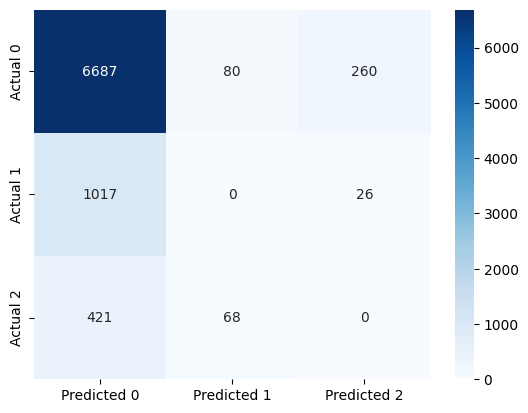

In [9]:
print(np.bincount(y))
print(np.bincount(y_test))
print(np.bincount(pred))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=[f"Predicted {i}" for i in range(len(unique))],
    yticklabels=[f"Actual {i}" for i in range(len(unique))]
)

In [ ]:
device = "cuda:0"
for batch_x, batch_y in dataloader_tr:
    batch_x = batch_x.to(device)
    batch_y = batch_y.to(device)
    if torch.isnan(batch_x).any() or torch.isinf(batch_x).any():
        for ind in torch.isnan(batch_x).nonzero():
            print(batch_x[ind])

        print('invalid input detected')

In [19]:
x.shape

(42792, 23)